# Water spatial segmentation - UNet training
Pixel table (5,013,504 rows x 12 columns) -> 16x16 patches, 11 input channels + 1 target (`Water occ prob`).

In [1]:
!pip install -q --upgrade gdown albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.1 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import numpy as np
import pandas as pd
import gdown

os.makedirs("/kaggle/working/drive_files", exist_ok=True)

file_id ="1K3qnpe29vjgcQ-b1_mifVHCiWpoLBhiy"
output_path = "/kaggle/working/drive_files/data.csv"

gdown.download(id=file_id, output=output_path, quiet=False)
df = pd.read_csv(output_path)

df.head()

Downloading...
From (original): https://drive.google.com/uc?id=1K3qnpe29vjgcQ-b1_mifVHCiWpoLBhiy
From (redirected): https://drive.google.com/uc?id=1K3qnpe29vjgcQ-b1_mifVHCiWpoLBhiy&confirm=t&uuid=2bc11d45-8df2-49bb-b024-0d26ebe258e2
To: /kaggle/working/drive_files/data.csv
100%|██████████| 356M/356M [00:02<00:00, 177MB/s]  


,Coastal aerosol,B,G,R,NIR,SWIR1,SWIR2,QA Band,Merit DEM,Copernicus DEM,ESA world cover map,Water occ prob
0,131.0,48.0,73.0,74.0,360.0,236.0,120.0,64.0,277.0,316.0,80.0,0.0
1,142.0,41.0,74.0,71.0,351.0,281.0,131.0,64.0,276.0,316.0,80.0,0.0
2,142.0,50.0,88.0,89.0,654.0,451.0,215.0,64.0,277.0,317.0,30.0,0.0
3,119.0,107.0,272.0,237.0,1941.0,1154.0,550.0,64.0,277.0,318.0,30.0,0.0
4,119.0,114.0,290.0,255.0,2173.0,1232.0,573.0,64.0,278.0,319.0,30.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5013504 entries, 0 to 5013503
Data columns (total 12 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Coastal aerosol      float64
 1   B                    float64
 2   G                    float64
 3   R                    float64
 4   NIR                  float64
 5   SWIR1                float64
 6   SWIR2                float64
 7   QA Band              float64
 8   Merit DEM            float64
 9   Copernicus DEM       float64
 10  ESA world cover map  float64
 11  Water occ prob       float64
dtypes: float64(12)
memory usage: 459.0 MB


In [4]:
# ---------------- settings ----------------
ALL_CHANNELS = ["Coastal aerosol", "B", "G", "R", "NIR", "SWIR1", "SWIR2",
                "QA Band", "Merit DEM", "Copernicus DEM", "ESA world cover map", "Water occ prob"]   # real band order

FEATURE_COLS = ["Coastal aerosol", "B", "G", "R", "NIR", "SWIR1", "SWIR2",
                "QA Band", "Merit DEM", "Copernicus DEM", "ESA world cover map"]   # 6 input channels
TARGET_COL   = 'Water occ prob'                                                                    # 1 target

IMG_SIZE   = 128        # every image is 128 x 128
PATCH_SIZE = 16         # UNet input 16 x 16
BATCH_SIZE = 64
EPOCHS     = 10
SEED       = 42

CKPT_DIR = "/kaggle/working/checkpoints" if os.path.exists("/kaggle/working") else "checkpoints"

In [5]:
# def process_channels(df, channels, all_channel_names):
#     """Keep only the requested channels (as float32). Raises a clear error if a name is wrong."""
#     unknown = [c for c in channels if c not in all_channel_names]
#     if unknown:
#         raise ValueError(f"Unknown channel names: {unknown}")
#     absent = [c for c in channels if c not in df.columns]
#     if absent:
#         raise KeyError(f"Columns missing from the dataframe: {absent}")

#     return df[channels].astype(np.float32).copy()


# #df = process_channels(df, FEATURE_COLS + [TARGET_COL], ALL_CHANNELS)

assert len(df) % (IMG_SIZE * IMG_SIZE) == 0, "rows must be a whole number of 128 x 128 images"
N_IMAGES = len(df) // (IMG_SIZE * IMG_SIZE)
print("images:", N_IMAGES, "| rows:", len(df))

images: 306 | rows: 5013504


## Pixel table -> 16x16 patches
Rows are stored image after image, each image row by row. Every image gives (128/16)^2 = 64 patches.

In [6]:
def df_to_patches(df, n_images, img_size=IMG_SIZE, patch=PATCH_SIZE):
    """Returns X (n_images, n_patches, 16, 16, 6) and y (n_images, n_patches, 16, 16)."""
    g = img_size // patch                                   # patches per side
    C = len(FEATURE_COLS)
    WATER_THRESHOLD = 75.0


    feats = df[FEATURE_COLS].to_numpy(np.float32).reshape(n_images, img_size, img_size, C)

    # Convert water occurrence probability/percentage -> binary mask
    target_raw = (
        df[TARGET_COL]
        .to_numpy(np.float32)
        .reshape(n_images, img_size, img_size)
    )

    target = (target_raw >= WATER_THRESHOLD).astype(np.float32)

    X = (
        feats
        .reshape(n_images, g, patch, g, patch, C)
        .transpose(0, 1, 3, 2, 4, 5)
        .reshape(n_images, g * g, patch, patch, C)
    )

    y = target.reshape(n_images, g, patch, g, patch).transpose(0, 1, 3, 2, 4).reshape(n_images, g * g, patch, patch)


    return X, y

  

X_all, y_all = df_to_patches(df, N_IMAGES)
print("X:", X_all.shape, "y:", y_all.shape)

X: (306, 64, 16, 16, 11) y: (306, 64, 16, 16)


In [7]:
from sklearn.model_selection import train_test_split

# split by IMAGE (so patches of one image never end up in two different splits)
idx = np.arange(N_IMAGES)
train_idx, tmp_idx = train_test_split(idx, test_size=0.4, random_state=SEED)
val_idx, test_idx  = train_test_split(tmp_idx, test_size=0.5, random_state=SEED)

def take(idx):
    return X_all[idx].reshape(-1, PATCH_SIZE, PATCH_SIZE, len(FEATURE_COLS)), y_all[idx].reshape(-1, PATCH_SIZE, PATCH_SIZE)

X_train, y_train = take(train_idx)
X_val,   y_val   = take(val_idx)
X_test,  y_test  = take(test_idx)
print("patches  train/val/test:", len(X_train), len(X_val), len(X_test))

# global per-band min / max, from the training images only (no leakage)
band_min = X_train.min(axis=(0, 1, 2))      # (6,)
band_max = X_train.max(axis=(0, 1, 2))
print("min:", band_min, "\nmax:", band_max)

patches  train/val/test: 11712 3904 3968
min: [-1.390e+03 -1.169e+03 -7.220e+02 -6.840e+02 -4.120e+02 -3.340e+02
 -2.510e+02  6.400e+01 -9.999e+03  8.000e+00  1.000e+01] 
max: [ 6568.  9659. 11368. 12041. 15841. 15252. 14647.   255.  2784.  2762.
   100.]


## Augmentation + Dataset
Geometric transforms are applied to the image **and** the mask together. Colour transforms and the 3-channel ImageNet `Normalize` were removed: they only make sense for RGB images, not for a 6-channel stack of NIR / SWIR / DEM / land-cover bands. Normalisation and tensor conversion happen inside the dataset.

In [8]:
import cv2
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=45, p=0.5,
                       interpolation=cv2.INTER_NEAREST, border_mode=cv2.BORDER_REFLECT_101),
    ToTensorV2(),
])      # called as transform(image=..., mask=...) -> the same random geometry hits both

val_transform = A.Compose([ToTensorV2()])


class SatellitePatchDataset(Dataset):
    def __init__(self, patches, masks, band_min, band_max, transform=None, eps=1e-6):
        self.patches = patches                      # (P, 16, 16, 6) raw values
        self.masks = masks                          # (P, 16, 16) values 0 / 1
        self.band_min = np.asarray(band_min, dtype=np.float32)
        self.band_range = np.maximum(np.asarray(band_max, dtype=np.float32) - self.band_min, eps)
        self.transform = transform or val_transform

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, i):
        x = (self.patches[i] - self.band_min) / self.band_range      # per-band [0, 1]
        x = np.clip(x, 0.0, 1.0).astype(np.float32)                   # (H, W, C)
        m = self.masks[i].astype(np.float32)                          # (H, W)

        out = self.transform(image=x, mask=m)
        return out["image"].float(), out["mask"].unsqueeze(0).float()   # (C,H,W), (1,H,W)


train_dataset = SatellitePatchDataset(X_train, y_train, band_min, band_max, train_transform)
val_dataset   = SatellitePatchDataset(X_val,   y_val,   band_min, band_max)
test_dataset  = SatellitePatchDataset(X_test,  y_test,  band_min, band_max)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

xb, yb = next(iter(train_loader))
print("batch:", xb.shape, yb.shape, "| mask values:", yb.unique().tolist())

/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


batch: torch.Size([64, 11, 16, 16]) torch.Size([64, 1, 16, 16]) | mask values: [0.0, 1.0]


## Model

# DeepLabv3 with resnet****

In [9]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.2 MB/s eta 0:00:0000:01


In [10]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp


class CombinedLoss(nn.Module):
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super().__init__()

        self.dice = smp.losses.DiceLoss(
            mode="binary",
            from_logits=True
        )

        self.bce = nn.BCEWithLogitsLoss()

        self.dice_weight = dice_weight
        self.bce_weight = bce_weight

    def forward(self, pred, target):

        target = target.float()

        dice = self.dice(pred, target)
        bce = self.bce(pred, target)

        return (
            self.dice_weight * dice
            + self.bce_weight * bce
        )


In [11]:
import os
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

CKPT_DIR = "/kaggle/working/checkpoints" if os.path.exists("/kaggle/working") else "checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

IN_CHANNELS = len(FEATURE_COLS) if 'FEATURE_COLS' in globals() else 11


# DeepLabV3 with a ResNet-34 backbone


def build_pretrained_model(freeze_encoder=False):
    # DeepLabV3+ (includes decoder skip-connection from encoder features)
    model_v3plus = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=11,
    classes=1,
)
    
    if freeze_encoder:
        # Freeze encoder parameters, but keep input conv trainable
        for param in model_v3plus.encoder.parameters():
            param.requires_grad = False
        # Unfreeze first conv layer to learn new channels
        for param in model_v3plus.encoder.conv1.parameters():
            param.requires_grad = True
            
    return model_v3plus

In [12]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
model = build_pretrained_model().to(device)

# ------------------------------ metrics ------------------------------
def batch_counts(logits, y, thr=0.5):
    """tp, fp, fn as a tensor that stays on the GPU (no .item() sync per batch)."""
    pred = torch.sigmoid(logits.float()) > thr
    true = y > 0.5
    return torch.stack([(pred & true).sum(), (pred & ~true).sum(), (~pred & true).sum()]).float()

def f1_iou(tp, fp, fn, eps=1e-7):
    return 2 * tp / (2 * tp + fp + fn + eps), tp / (tp + fp + fn + eps)


# ------------------------------ training ------------------------------
def fit(model, train_loader, val_loader, optimizer, criterion, epochs, PATH,
        patience=10, scheduler=None, threshold=0.50, monitor="val_loss", use_amp=True, grad_clip=1.0):
    """monitor: 'val_loss' (lower is better) or 'val_iou' / 'val_f1' (higher is better).
    ReduceLROnPlateau must use the matching mode: 'min' for val_loss, 'max' for val_iou / val_f1."""
    os.makedirs(os.path.dirname(PATH) or ".", exist_ok=True)
    best_model_path = os.path.join(os.path.dirname(PATH), "best_model.pt")
    higher_better = monitor != "val_loss"
    amp = use_amp and device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=amp)

    keys = ['train_loss', 'val_loss', 'train_f1', 'val_f1', 'train_iou', 'val_iou', 'lr']
    history = {k: [] for k in keys}
    start_epoch, bad_epochs = 0, 0
    best = -float('inf') if higher_better else float('inf')

    if os.path.exists(PATH):
        print(f"Loading checkpoint from file: {PATH}")
        ckpt = torch.load(PATH, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        if scheduler is not None and 'scheduler_state_dict' in ckpt:
            scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        if ckpt.get('monitor') == monitor:
            best = ckpt.get('best_score', best)
        old = ckpt.get('history', {})
        history = {k: old.get(k, []) for k in keys}
        print(f"Resuming training from epoch {start_epoch + 1}")
    else:
        print("No checkpoint file found, starting training from scratch.")

    end_epoch = start_epoch + epochs
    for epoch in range(start_epoch, end_epoch):
        # ---- train ----
        model.train()
        train_loss, counts = 0.0, torch.zeros(3, device=device)
        for X, y in train_loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=amp):
                out = model(X)
            loss = criterion(out, y)
            scaler.scale(loss).backward()
            if grad_clip:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.detach()
            counts += batch_counts(out.detach(), y, threshold)
        train_loss = (train_loss / len(train_loader)).item()
        train_f1, train_iou = [v.item() for v in f1_iou(*counts)]

        # ---- validation ----
        model.eval()
        val_loss, counts = 0.0, torch.zeros(3, device=device)
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
                with torch.autocast(device_type=device.type, enabled=amp):
                    out = model(X)
                val_loss += criterion(out, y).detach()
                counts += batch_counts(out, y, threshold)
        val_loss = (val_loss / len(val_loader)).item()
        val_f1, val_iou = [v.item() for v in f1_iou(*counts)]

        lr = optimizer.param_groups[0]['lr']
        for k, v in zip(keys, [train_loss, val_loss, train_f1, val_f1, train_iou, val_iou, lr]):
            history[k].append(v)
        print(f"Epoch [{epoch + 1:>3d}/{end_epoch:>3d}] loss: {train_loss:.4f}/{val_loss:.4f} | "
              f"F1: {train_f1:.4f}/{val_f1:.4f} | IoU: {train_iou:.4f}/{val_iou:.4f} | lr: {lr:.2e}")

        score = {"val_loss": val_loss, "val_f1": val_f1, "val_iou": val_iou}[monitor]

        # ---- scheduler: stepped exactly ONCE per epoch ----
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(score)
            else:                                    # cosine, step, ... (per epoch)
                scheduler.step()

        # ---- checkpoints + early stopping ----
        improved = score > best if higher_better else score < best
        if improved:
            best, bad_epochs = score, 0
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                        'monitor': monitor, 'score': score}, best_model_path)
            print(f"--> Saved new best model ({monitor}={score:.4f}) to {best_model_path}")
        else:
            bad_epochs += 1

        ckpt = {'epoch': epoch, 'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_score': best, 'monitor': monitor, 'history': history}
        if scheduler is not None:
            ckpt['scheduler_state_dict'] = scheduler.state_dict()
        torch.save(ckpt, PATH)

        if bad_epochs >= patience:
            print(f"Early stopping: no {monitor} improvement for {patience} epochs.")
            break

    return history, PATH

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

In [13]:
criterion = CombinedLoss().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
MODEL_PATH = os.path.join(CKPT_DIR, "UNET_model.pt")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)

history, last_checkpoint = fit(model, train_loader, val_loader, optimizer, criterion,
                               epochs=20, PATH=MODEL_PATH, patience=10, scheduler=scheduler)

No checkpoint file found, starting training from scratch.
Epoch [  1/ 20] loss: 0.1198/0.0991 | F1: 0.8843/0.9401 | IoU: 0.7925/0.8870 | lr: 1.00e-03
--> Saved new best model (val_loss=0.0991) to /kaggle/working/checkpoints/best_model.pt
Epoch [  2/ 20] loss: 0.0498/0.0920 | F1: 0.9469/0.9493 | IoU: 0.8992/0.9036 | lr: 1.00e-03
--> Saved new best model (val_loss=0.0920) to /kaggle/working/checkpoints/best_model.pt
Epoch [  3/ 20] loss: 0.0473/0.0914 | F1: 0.9514/0.9483 | IoU: 0.9073/0.9017 | lr: 1.00e-03
--> Saved new best model (val_loss=0.0914) to /kaggle/working/checkpoints/best_model.pt
Epoch [  4/ 20] loss: 0.0430/0.0880 | F1: 0.9545/0.9523 | IoU: 0.9130/0.9089 | lr: 1.00e-03
--> Saved new best model (val_loss=0.0880) to /kaggle/working/checkpoints/best_model.pt
Epoch [  5/ 20] loss: 0.0390/0.0857 | F1: 0.9581/0.9581 | IoU: 0.9195/0.9195 | lr: 1.00e-03
--> Saved new best model (val_loss=0.0857) to /kaggle/working/checkpoints/best_model.pt
Epoch [  6/ 20] loss: 0.0390/0.0842 | F1: 

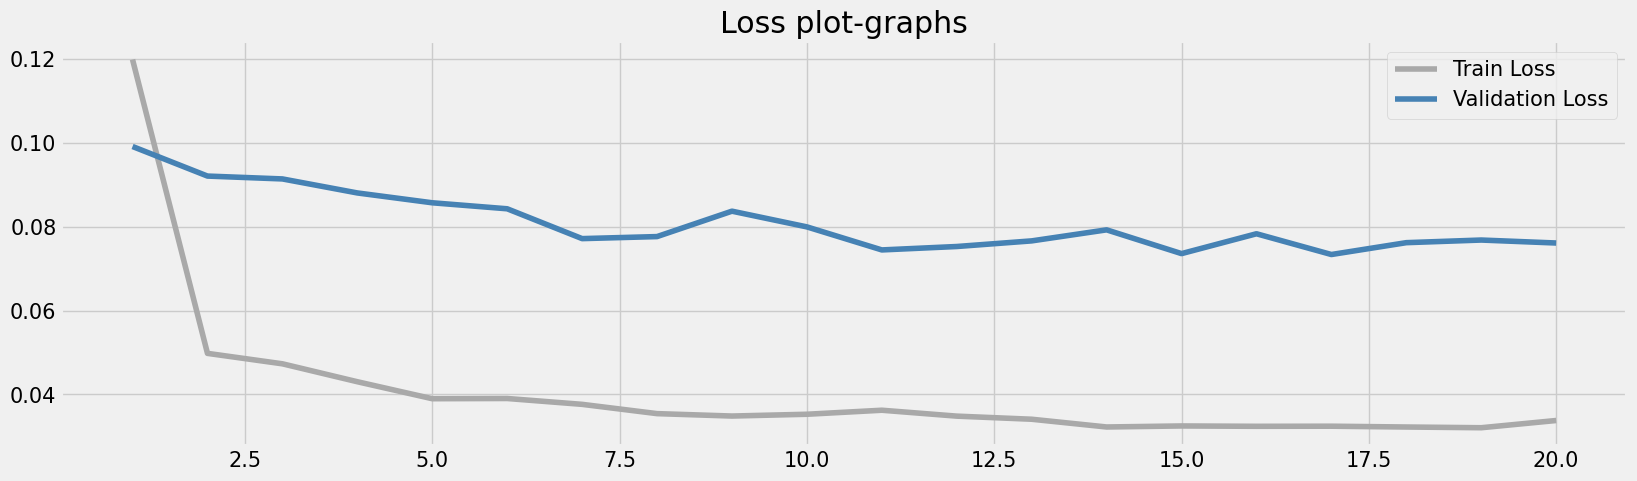

In [14]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)
with plt.style.context('fivethirtyeight'):
    plt.figure(figsize=(18, 5))
    plt.rcParams['font.size'] = 15
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='darkgray')
    plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='steelblue')
    plt.title('Loss plot-graphs')
    plt.legend()
    plt.show()

In [15]:
criterion = CombinedLoss().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
MODEL_PATH = os.path.join(CKPT_DIR, "UNET_model.pt")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)

history, last_checkpoint = fit(model, train_loader, val_loader, optimizer, criterion,
                               epochs=20, PATH=MODEL_PATH, patience=10, scheduler=scheduler)

Loading checkpoint from file: /kaggle/working/checkpoints/UNET_model.pt
Resuming training from epoch 21
Epoch [ 21/ 40] loss: 0.0311/0.0745 | F1: 0.9671/0.9657 | IoU: 0.9364/0.9336 | lr: 1.00e-03
Epoch [ 22/ 40] loss: 0.0296/0.0738 | F1: 0.9686/0.9670 | IoU: 0.9392/0.9360 | lr: 5.00e-04
Epoch [ 23/ 40] loss: 0.0312/0.0733 | F1: 0.9681/0.9674 | IoU: 0.9381/0.9369 | lr: 5.00e-04
--> Saved new best model (val_loss=0.0733) to /kaggle/working/checkpoints/best_model.pt
Epoch [ 24/ 40] loss: 0.0289/0.0736 | F1: 0.9694/0.9676 | IoU: 0.9406/0.9372 | lr: 5.00e-04
Epoch [ 25/ 40] loss: 0.0288/0.0718 | F1: 0.9691/0.9697 | IoU: 0.9401/0.9412 | lr: 5.00e-04
--> Saved new best model (val_loss=0.0718) to /kaggle/working/checkpoints/best_model.pt
Epoch [ 26/ 40] loss: 0.0283/0.0681 | F1: 0.9694/0.9698 | IoU: 0.9406/0.9414 | lr: 5.00e-04
--> Saved new best model (val_loss=0.0681) to /kaggle/working/checkpoints/best_model.pt
Epoch [ 27/ 40] loss: 0.0279/0.0684 | F1: 0.9700/0.9697 | IoU: 0.9417/0.9411 | l

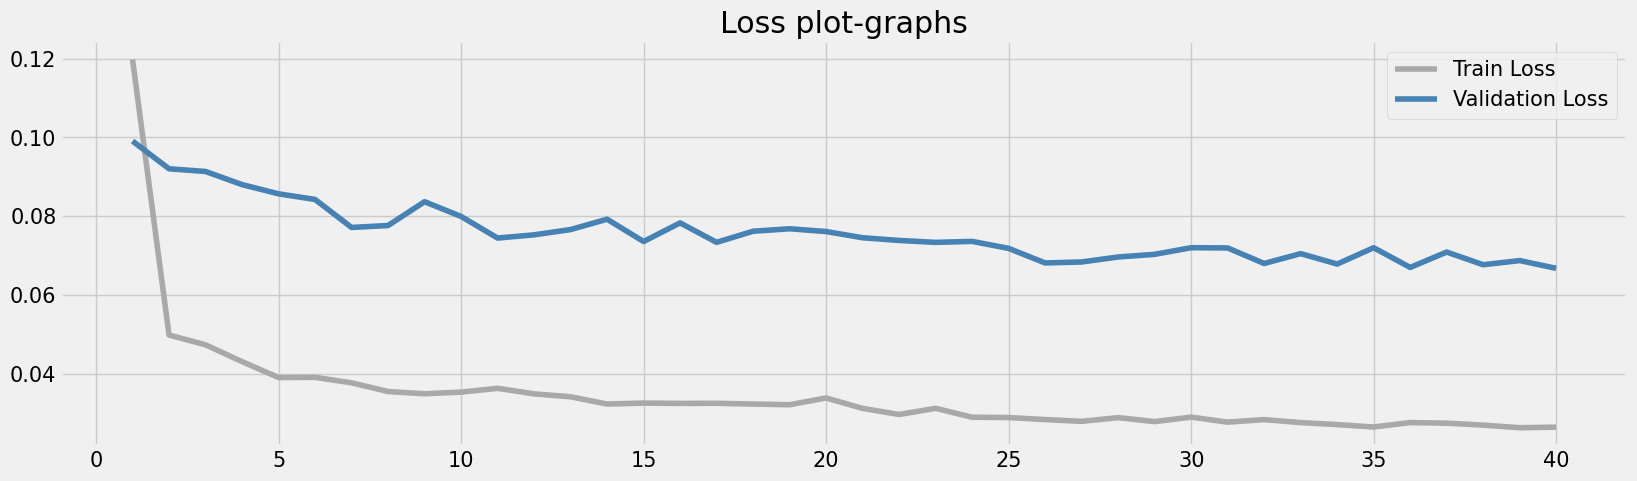

In [16]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)
with plt.style.context('fivethirtyeight'):
    plt.figure(figsize=(18, 5))
    plt.rcParams['font.size'] = 15
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='darkgray')
    plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='steelblue')
    plt.title('Loss plot-graphs')
    plt.legend()
    plt.show()

In [17]:
criterion = CombinedLoss().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
MODEL_PATH = os.path.join(CKPT_DIR, "UNET_model.pt")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)

history, last_checkpoint = fit(model, train_loader, val_loader, optimizer, criterion,
                               epochs=20, PATH=MODEL_PATH, patience=10, scheduler=scheduler)

Loading checkpoint from file: /kaggle/working/checkpoints/UNET_model.pt
Resuming training from epoch 41
Epoch [ 41/ 60] loss: 0.0261/0.0670 | F1: 0.9716/0.9717 | IoU: 0.9448/0.9450 | lr: 2.50e-04
Epoch [ 42/ 60] loss: 0.0265/0.0670 | F1: 0.9719/0.9713 | IoU: 0.9453/0.9441 | lr: 2.50e-04
Epoch [ 43/ 60] loss: 0.0262/0.0670 | F1: 0.9720/0.9716 | IoU: 0.9456/0.9448 | lr: 2.50e-04
Epoch [ 44/ 60] loss: 0.0263/0.0669 | F1: 0.9719/0.9710 | IoU: 0.9453/0.9435 | lr: 2.50e-04
Epoch [ 45/ 60] loss: 0.0258/0.0651 | F1: 0.9728/0.9720 | IoU: 0.9471/0.9454 | lr: 1.25e-04
--> Saved new best model (val_loss=0.0651) to /kaggle/working/checkpoints/best_model.pt
Epoch [ 46/ 60] loss: 0.0257/0.0678 | F1: 0.9726/0.9718 | IoU: 0.9466/0.9451 | lr: 1.25e-04
Epoch [ 47/ 60] loss: 0.0252/0.0656 | F1: 0.9724/0.9712 | IoU: 0.9464/0.9441 | lr: 1.25e-04
Epoch [ 48/ 60] loss: 0.0259/0.0671 | F1: 0.9726/0.9725 | IoU: 0.9467/0.9464 | lr: 1.25e-04
Epoch [ 49/ 60] loss: 0.0255/0.0671 | F1: 0.9727/0.9716 | IoU: 0.9468/0.

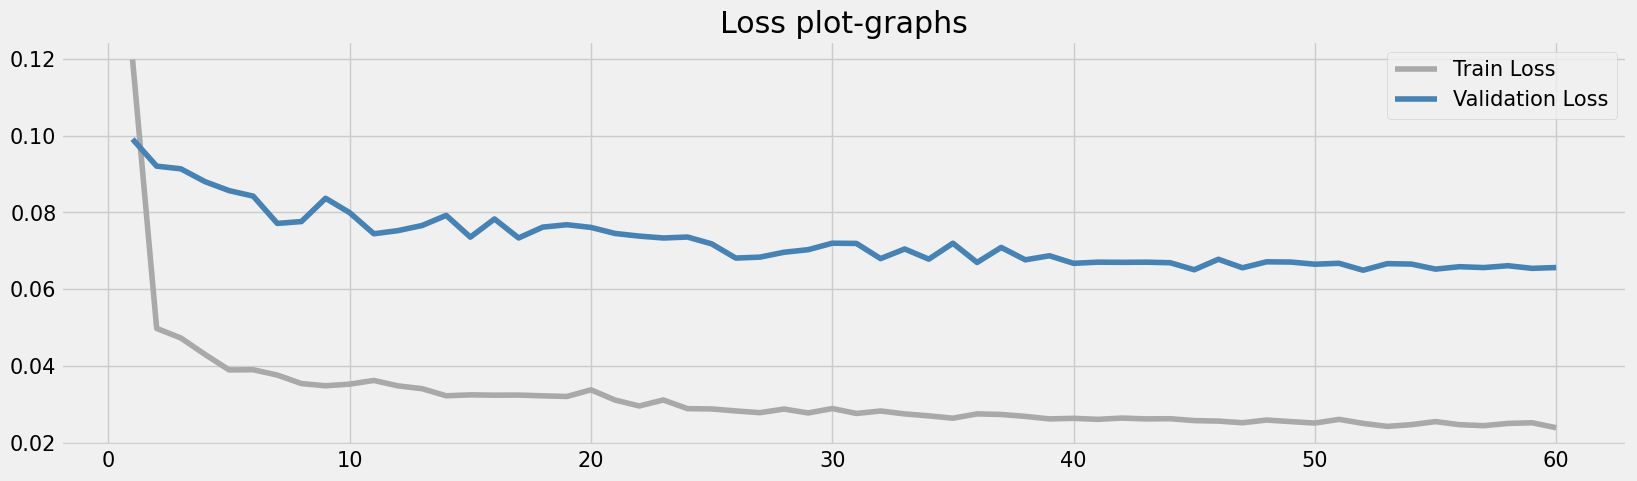

In [18]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)
with plt.style.context('fivethirtyeight'):
    plt.figure(figsize=(18, 5))
    plt.rcParams['font.size'] = 15
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='darkgray')
    plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='steelblue')
    plt.title('Loss plot-graphs')
    plt.legend()
    plt.show()

IoU: 0.9229 | F1: 0.9599
Confusion matrix (rows = true, cols = predicted) [non-water, water]:
 [[914445   2981]
 [  4830  93552]]


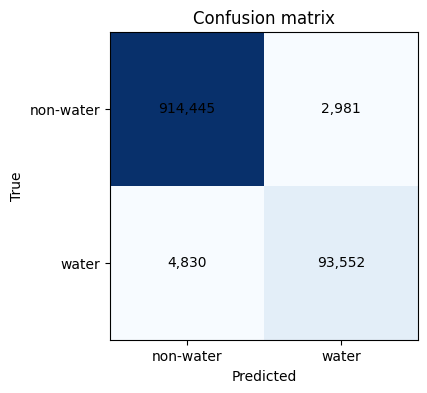

In [19]:
from sklearn.metrics import confusion_matrix

def test_model(model, loader, threshold=0.5, plot=True):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X, y in loader:
            prob = torch.sigmoid(model(X.to(device)))
            preds.append((prob > threshold).cpu().numpy().ravel())
            targets.append(y.numpy().ravel())
    preds = np.concatenate(preds).astype(int)
    targets = np.concatenate(targets).astype(int)

    cm = confusion_matrix(targets, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    iou = tp / max(tp + fp + fn, 1)
    f1 = 2 * tp / max(2 * tp + fp + fn, 1)
    print(f"IoU: {iou:.4f} | F1: {f1:.4f}")
    print("Confusion matrix (rows = true, cols = predicted) [non-water, water]:\n", cm)

    if plot:
        plt.figure(figsize=(4, 4))
        plt.imshow(cm, cmap="Blues")
        for (r, c), v in np.ndenumerate(cm):
            plt.text(c, r, f"{v:,}", ha="center", va="center")
        plt.xticks([0, 1], ["non-water", "water"]); plt.yticks([0, 1], ["non-water", "water"])
        plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix")
        plt.show()
    return {"iou": iou, "f1": f1, "confusion_matrix": cm}


best = torch.load(os.path.join(CKPT_DIR, "best_model.pt"), map_location=device)
model.load_state_dict(best['model_state_dict'])
test_results = test_model(model, test_loader)

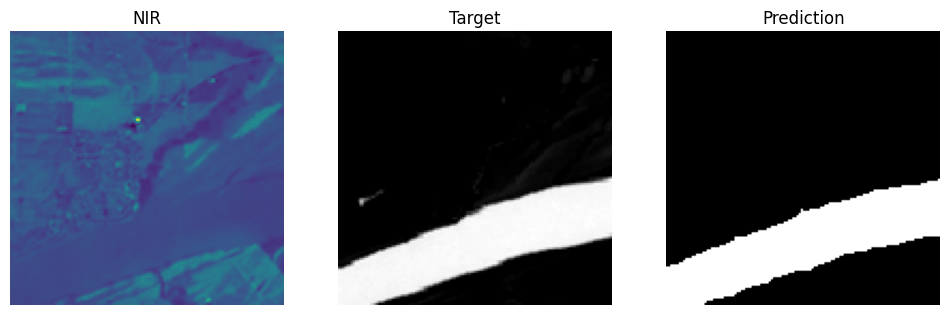

In [39]:
def predict_image(model, image, band_min=band_min, band_max=band_max, patch=PATCH_SIZE, threshold=0.5):
    """image: path (.tif / .npy) or array (H, W, 12) or (H, W, 6) in FEATURE_COLS order.
    Any H x W works (the image is padded to a multiple of 16, predicted patch by patch and stitched back).
    Returns (probability map, binary mask), both (H, W)."""
    if isinstance(image, str):
        if image.lower().endswith(".npy"):
            image = np.load(image)
        else:
            import tifffile
            image = tifffile.imread(image)
    image = np.asarray(image)
    if image.ndim == 3 and image.shape[0] in (6, 12) and image.shape[-1] not in (6, 12):
        image = np.moveaxis(image, 0, -1)                                   # (C,H,W) -> (H,W,C)
    if image.shape[-1] == 12:
        image = image[..., [ALL_CHANNELS.index(c) for c in FEATURE_COLS]]    # keep the 6 input channels
    assert image.shape[-1] == len(FEATURE_COLS), f"expected 6 or 12 channels, got {image.shape[-1]}"

    x = np.clip((image.astype(np.float32) - band_min) / np.maximum(band_max - band_min, 1e-6), 0, 1)
    H, W, C = x.shape
    pad_h, pad_w = (-H) % patch, (-W) % patch
    x = np.pad(x, ((0, pad_h), (0, pad_w), (0, 0)), mode="reflect")
    Hp, Wp = x.shape[:2]
    gh, gw = Hp // patch, Wp // patch

    tiles = x.reshape(gh, patch, gw, patch, C).transpose(0, 2, 4, 1, 3).reshape(-1, C, patch, patch)
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(tiles), 256):
            batch = torch.from_numpy(np.ascontiguousarray(tiles[i:i + 256])).to(device)
            probs.append(torch.sigmoid(model(batch)).cpu().numpy())
    probs = np.concatenate(probs)[:, 0]                                       # (n_tiles, 16, 16)

    prob_map = probs.reshape(gh, gw, patch, patch).transpose(0, 2, 1, 3).reshape(Hp, Wp)[:H, :W]
    return prob_map, (prob_map > threshold).astype(np.uint8)


# example: one 128 x 128 test image rebuilt from the table (raw 6 channels)
i = test_idx[5]
img = df[FEATURE_COLS].to_numpy(np.float32)[i * IMG_SIZE**2:(i + 1) * IMG_SIZE**2].reshape(IMG_SIZE, IMG_SIZE, -1)
true_mask = df[TARGET_COL].to_numpy(np.float32)[i * IMG_SIZE**2:(i + 1) * IMG_SIZE**2].reshape(IMG_SIZE, IMG_SIZE)
prob_map, pred_mask = predict_image(model, img)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img[..., 0], cmap="viridis"); ax[0].set_title("NIR")
ax[1].imshow(true_mask, cmap="gray"); ax[1].set_title("Target")
ax[2].imshow(pred_mask, cmap="gray"); ax[2].set_title("Prediction")
for a in ax: a.axis("off")
plt.show()

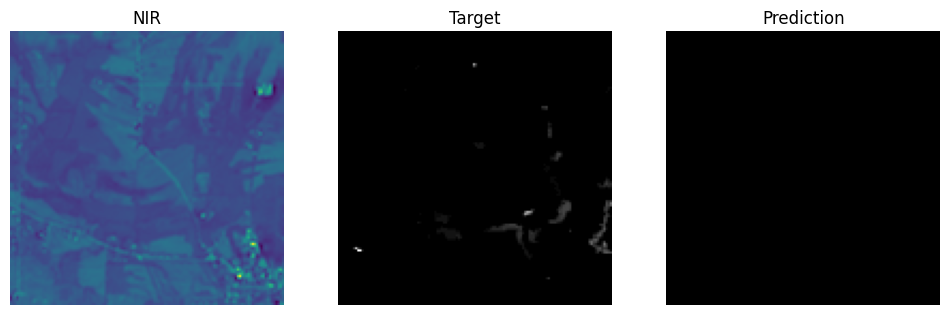

In [20]:
def predict_image(model, image, band_min=band_min, band_max=band_max, patch=PATCH_SIZE, threshold=0.5):
    """image: path (.tif / .npy) or array (H, W, 12) or (H, W, 6) in FEATURE_COLS order.
    Any H x W works (the image is padded to a multiple of 16, predicted patch by patch and stitched back).
    Returns (probability map, binary mask), both (H, W)."""
    if isinstance(image, str):
        if image.lower().endswith(".npy"):
            image = np.load(image)
        else:
            import tifffile
            image = tifffile.imread(image)
    image = np.asarray(image)
    if image.ndim == 3 and image.shape[0] in (6, 12) and image.shape[-1] not in (6, 12):
        image = np.moveaxis(image, 0, -1)                                   # (C,H,W) -> (H,W,C)
    if image.shape[-1] == 12:
        image = image[..., [ALL_CHANNELS.index(c) for c in FEATURE_COLS]]    # keep the 6 input channels
    assert image.shape[-1] == len(FEATURE_COLS), f"expected 6 or 12 channels, got {image.shape[-1]}"

    x = np.clip((image.astype(np.float32) - band_min) / np.maximum(band_max - band_min, 1e-6), 0, 1)
    H, W, C = x.shape
    pad_h, pad_w = (-H) % patch, (-W) % patch
    x = np.pad(x, ((0, pad_h), (0, pad_w), (0, 0)), mode="reflect")
    Hp, Wp = x.shape[:2]
    gh, gw = Hp // patch, Wp // patch

    tiles = x.reshape(gh, patch, gw, patch, C).transpose(0, 2, 4, 1, 3).reshape(-1, C, patch, patch)
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(tiles), 256):
            batch = torch.from_numpy(np.ascontiguousarray(tiles[i:i + 256])).to(device)
            probs.append(torch.sigmoid(model(batch)).cpu().numpy())
    probs = np.concatenate(probs)[:, 0]                                       # (n_tiles, 16, 16)

    prob_map = probs.reshape(gh, gw, patch, patch).transpose(0, 2, 1, 3).reshape(Hp, Wp)[:H, :W]
    return prob_map, (prob_map > threshold).astype(np.uint8)


# example: one 128 x 128 test image rebuilt from the table (raw 6 channels)
i = test_idx[55]
img = df[FEATURE_COLS].to_numpy(np.float32)[i * IMG_SIZE**2:(i + 1) * IMG_SIZE**2].reshape(IMG_SIZE, IMG_SIZE, -1)
true_mask = df[TARGET_COL].to_numpy(np.float32)[i * IMG_SIZE**2:(i + 1) * IMG_SIZE**2].reshape(IMG_SIZE, IMG_SIZE)
prob_map, pred_mask = predict_image(model, img)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img[..., 0], cmap="viridis"); ax[0].set_title("NIR")
ax[1].imshow(true_mask, cmap="gray"); ax[1].set_title("Target")
ax[2].imshow(pred_mask, cmap="gray"); ax[2].set_title("Prediction")
for a in ax: a.axis("off")
plt.show()

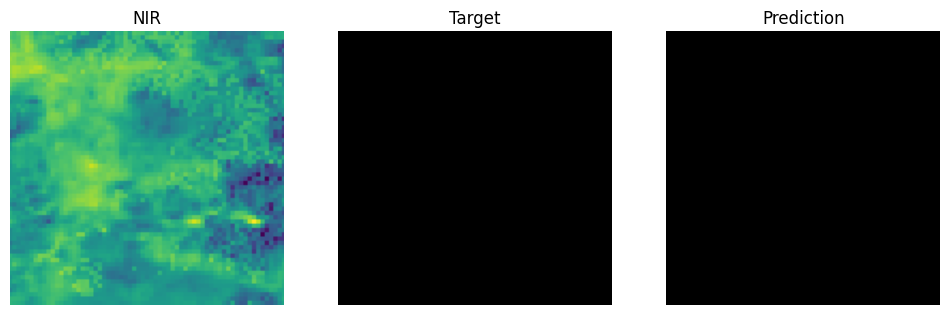

In [46]:
def predict_image(model, image, band_min=band_min, band_max=band_max, patch=PATCH_SIZE, threshold=0.5):
    """image: path (.tif / .npy) or array (H, W, 12) or (H, W, 6) in FEATURE_COLS order.
    Any H x W works (the image is padded to a multiple of 16, predicted patch by patch and stitched back).
    Returns (probability map, binary mask), both (H, W)."""
    if isinstance(image, str):
        if image.lower().endswith(".npy"):
            image = np.load(image)
        else:
            import tifffile
            image = tifffile.imread(image)
    image = np.asarray(image)
    if image.ndim == 3 and image.shape[0] in (6, 12) and image.shape[-1] not in (6, 12):
        image = np.moveaxis(image, 0, -1)                                   # (C,H,W) -> (H,W,C)
    if image.shape[-1] == 12:
        image = image[..., [ALL_CHANNELS.index(c) for c in FEATURE_COLS]]    # keep the 6 input channels
    assert image.shape[-1] == len(FEATURE_COLS), f"expected 6 or 12 channels, got {image.shape[-1]}"

    x = np.clip((image.astype(np.float32) - band_min) / np.maximum(band_max - band_min, 1e-6), 0, 1)
    H, W, C = x.shape
    pad_h, pad_w = (-H) % patch, (-W) % patch
    x = np.pad(x, ((0, pad_h), (0, pad_w), (0, 0)), mode="reflect")
    Hp, Wp = x.shape[:2]
    gh, gw = Hp // patch, Wp // patch

    tiles = x.reshape(gh, patch, gw, patch, C).transpose(0, 2, 4, 1, 3).reshape(-1, C, patch, patch)
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(tiles), 256):
            batch = torch.from_numpy(np.ascontiguousarray(tiles[i:i + 256])).to(device)
            probs.append(torch.sigmoid(model(batch)).cpu().numpy())
    probs = np.concatenate(probs)[:, 0]                                       # (n_tiles, 16, 16)

    prob_map = probs.reshape(gh, gw, patch, patch).transpose(0, 2, 1, 3).reshape(Hp, Wp)[:H, :W]
    return prob_map, (prob_map > threshold).astype(np.uint8)


# example: one 128 x 128 test image rebuilt from the table (raw 6 channels)
i = test_idx[40]
img = df[FEATURE_COLS].to_numpy(np.float32)[i * IMG_SIZE**2:(i + 1) * IMG_SIZE**2].reshape(IMG_SIZE, IMG_SIZE, -1)
true_mask = df[TARGET_COL].to_numpy(np.float32)[i * IMG_SIZE**2:(i + 1) * IMG_SIZE**2].reshape(IMG_SIZE, IMG_SIZE)
prob_map, pred_mask = predict_image(model, img)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img[..., 0], cmap="viridis"); ax[0].set_title("NIR")
ax[1].imshow(true_mask, cmap="gray"); ax[1].set_title("Target")
ax[2].imshow(pred_mask, cmap="gray"); ax[2].set_title("Prediction")
for a in ax: a.axis("off")
plt.show()